In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from collections import Counter
warnings.filterwarnings('ignore')

from sklearn.datasets import (make_classification, make_regression, load_breast_cancer, load_diabetes)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
accuracy_score, precision_score, recall_score, f1_score,
roc_auc_score, roc_curve, precision_recall_curve,
confusion_matrix, classification_report,
mean_squared_error, mean_absolute_error, r2_score,
ConfusionMatrixDisplay
)

In [5]:
#Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
np.random.seed(42)

print("All libraries loaded successfully!")
print(f"Numpy: {np.__version__} | Pandas: {pd.__version__}")

All libraries loaded successfully!
Numpy: 2.4.6 | Pandas: 3.0.3


In [9]:
#Dataset preparation

#Classification: Breast Cancer Dataset
cancer = load_breast_cancer()
X_clf, y_clf = cancer.data, cancer.target
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

#Feature scaling
scaler_c = StandardScaler()
X_train_c = scaler_c.fit_transform(X_train_c)
X_test_c = scaler_c.fit_transform(X_test_c)

#Diabetes dataset
diabetes = load_diabetes()
X_reg, y_reg = diabetes.data, diabetes.target

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

scaler_r = StandardScaler()
X_train_r = scaler_r.fit_transform(X_train_r)
X_test_r = scaler_r.transform(X_test_r)

#data summary
print("CLASSIFICATION DATASET (Breast Cancer)")
print(f" Train: {X_train_c.shape} | Test: {X_test_c.shape}")
print(f" Class balance - Malignant: {(y_clf==0).sum()} | Benign: {(y_clf==1).sum()}\n")
print("REGRESSION DATASET (Diabetes)")
print(f" Train: {X_train_r.shape} | Test: {X_test_r.shape}")
print(f" Taget range: [{y_reg.min():.0f}], {y_reg.max():.0f}]")

CLASSIFICATION DATASET (Breast Cancer)
 Train: (455, 30) | Test: (114, 30)
 Class balance - Malignant: 212 | Benign: 357

REGRESSION DATASET (Diabetes)
 Train: (353, 10) | Test: (89, 10)
 Taget range: [25], 346]


1st 5 Features:  ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']
Class imbalance ration: 1.68


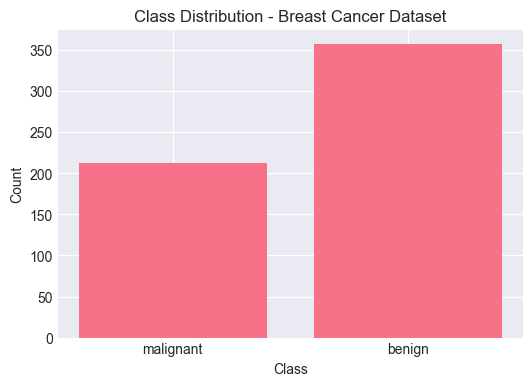

In [11]:
#BREAST CANSER DATASET
#Task 1
print("1st 5 Features: ", cancer.feature_names[0:5])

#Task 2
class_counts = Counter(y_clf)
majority = max(class_counts.values())
minority = min(class_counts.values())
imbalance_ration = majority / minority
print(f"Class imbalance ration: {imbalance_ration:.2f}")

#Task 3
plt.figure(figsize=(6,4))
labels = [cancer.target_names[i] for i in class_counts.keys()]
counts = list(class_counts.values())
plt.bar(labels, counts)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution - Breast Cancer Dataset")
plt.show()

Logistic Regression: Accuracy = 0.9825
Ramdom Forest: Accuracy = 0.9649
Gradient Boosting: Accuracy = 0.9649


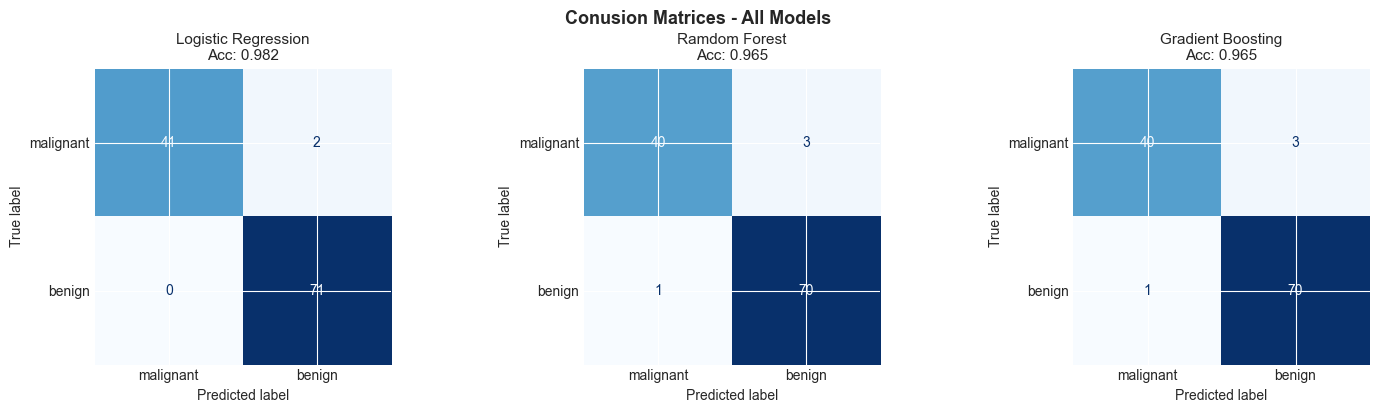

In [15]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Ramdom Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_c, y_train_c)
    y_pred = model.predict(X_test_c)
    y_proba = model.predict_proba(X_test_c)[:,-1]

    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'accuracy': accuracy_score(y_test_c, y_pred),
        'cm': confusion_matrix(y_test_c, y_pred)
    }
    print(f"{name}: Accuracy = {results[name]['accuracy']:.4f}")

#Visualize confusion matrix
fig, axes = plt.subplots(1,3, figsize=(15,4))

for ax, (name, res) in zip(axes, results.items()):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=res['cm'],
        display_labels=cancer.target_names
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{name}\nAcc: {res['accuracy']:.3f}", fontsize=11)
plt.tight_layout()
plt.suptitle("Conusion Matrices - All Models", y=1.02, fontsize=13, fontweight='bold')
plt.show()

In [16]:
#Task 2: Confusion Matrix Manual
#1. Redo Logistic Regression Confusion Matrix
y_true = np.array(y_test_c)
y_pred = np.array(results['Logistic Regression']['y_pred'])

TP, TN, FP, FN = 0,0,0,0
for actual, predicted in zip(y_true, y_pred):
    if actual==1 and predicted==1:
        TP = TP + 1
    elif actual==0 and predicted==0:
        TN = TN + 1
    elif actual==0 and predicted==1:
        FP = FP + 1
    elif actual==1 and predicted==0:
        FN = FN + 1
cmatrix = np.array([
    [TN, FP], 
    [FN, TP]
])
print('Confusion Matrix:')
print(cmatrix)
#2. TP, FP, TN, FN values manually
print('True Positive: ', TP) 
print('False Positive: ', FP) 
print('True Negative: ', TN) 
print('False Negative: ', FN) 

#3 Calculate Accuracy from Scratch
total = TP + FP + TN + FN
acc = (TP+TN)/total
print('Accuracy: ', acc)

Confusion Matrix:
[[41  2]
 [ 0 71]]
True Positive:  71
False Positive:  2
True Negative:  41
False Negative:  0
Accuracy:  0.9824561403508771
